# Example of using fuctions from package tools

Set up the path for the execution.

In [1]:
import sys
import os
import pandas as pd

# Define the absolute path of the directory
home_dir = r'D:\Storage\ETH\Thesis\Code'
lib_dir = os.path.join(home_dir, 'EMIP-Toolkit') 
tools_dir = os.path.join(home_dir, 'Playground')
sys.path.append(tools_dir)
sys.path.append(lib_dir)

from emtk import parsers, visualization, util, aoi

Set the experiment_id and trial_id we want to study.

In [2]:
# trial_id: 2 for vehicle, 5 for rectangle
experiment_id = '100'
trial_id = '2'
sample_size = 8

Parse the data.

In [3]:
from tools import path_similarity

# Parse EMIP data
eye_events, samples = parsers.EMIP(sample_size)

Please cite this paper:  https://dl.acm.org/doi/abs/10.1145/3448018.3457425
parsing file: 100_rawdata.tsv
parsing file: 101_rawdata.tsv
parsing file: 101_rawdata.tsv
parsing file: 102_rawdata.tsv
parsing file: 102_rawdata.tsv
parsing file: 103_rawdata.tsv
parsing file: 103_rawdata.tsv
parsing file: 104_rawdata.tsv
parsing file: 104_rawdata.tsv
parsing file: 105_rawdata.tsv
parsing file: 105_rawdata.tsv
parsing file: 106_rawdata.tsv
parsing file: 106_rawdata.tsv
parsing file: 107_rawdata.tsv
parsing file: 107_rawdata.tsv


Specify the experiment and trial we want to analyze for the scanpath

In [4]:
# exp = ('experiment_id', 'trial_id')

exp_a = ('103', '2')
exp_b = ('104', '2')

Generate image specified experiment and trial.

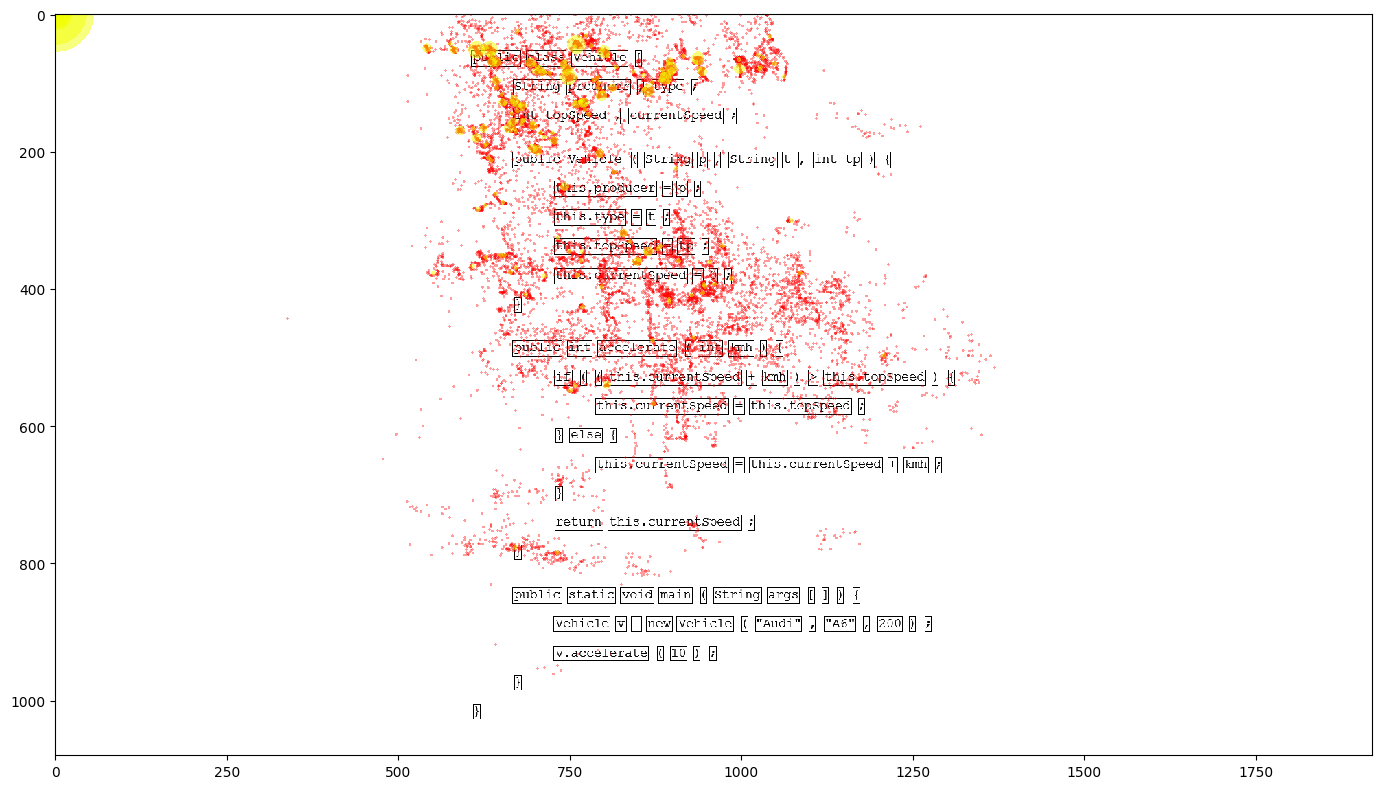

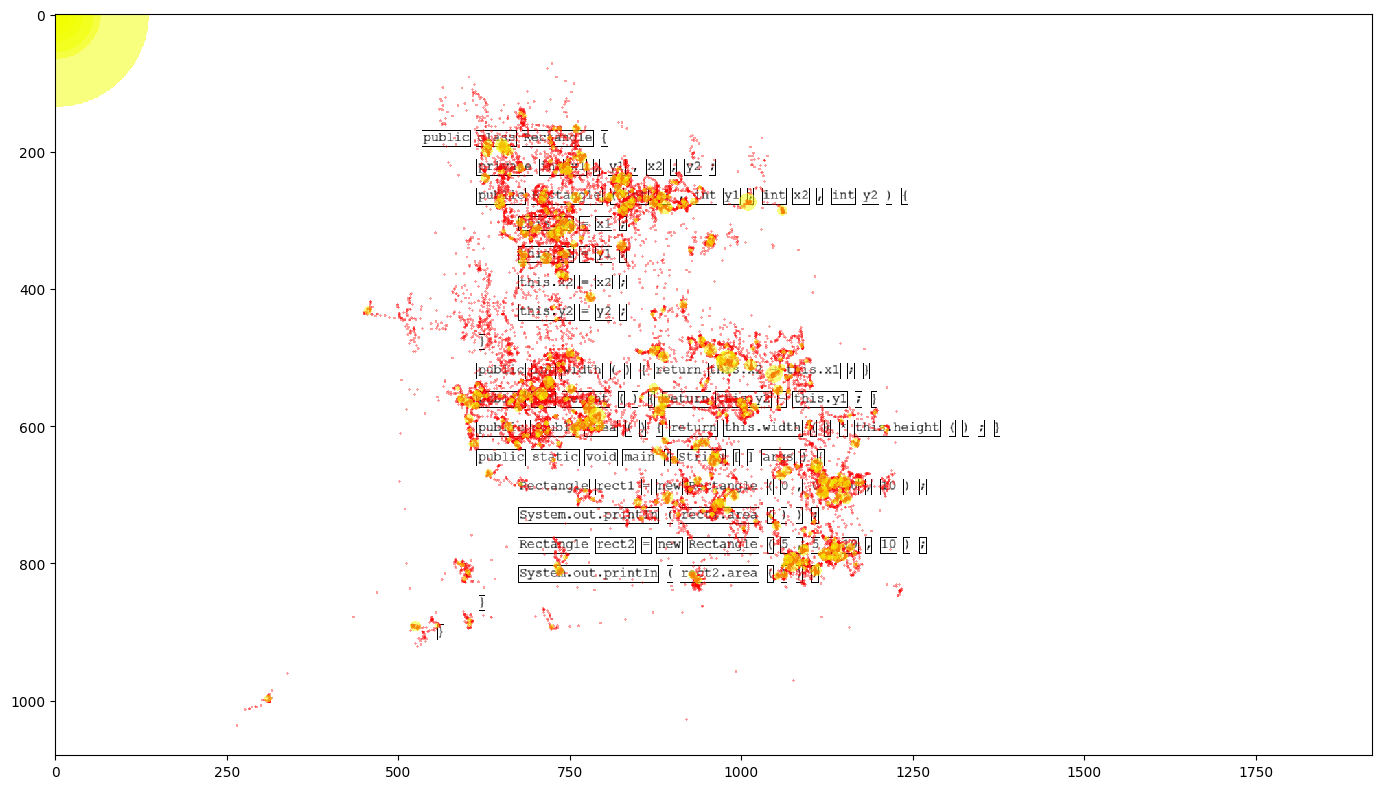

In [5]:
from tools import image_generation

# possible options for image_type are "heatmap", "fixation_duration", "fixation_timeline", "all"
# when query is set to True, the experiment_id will be determined by the query

image_generation.emip_gen(exp = exp_a, eye_events = eye_events, samples = samples, query = False, image_type = 'all')

image_generation.emip_gen(exp = exp_b, eye_events = eye_events, samples = samples, query = True, image_type = 'all')

Use the python library multimatch_gaze to compute path similarity.\
We use 2 random generated scan-path as baseline to normalize the final value.\ 

final_value = original_value - base_line.

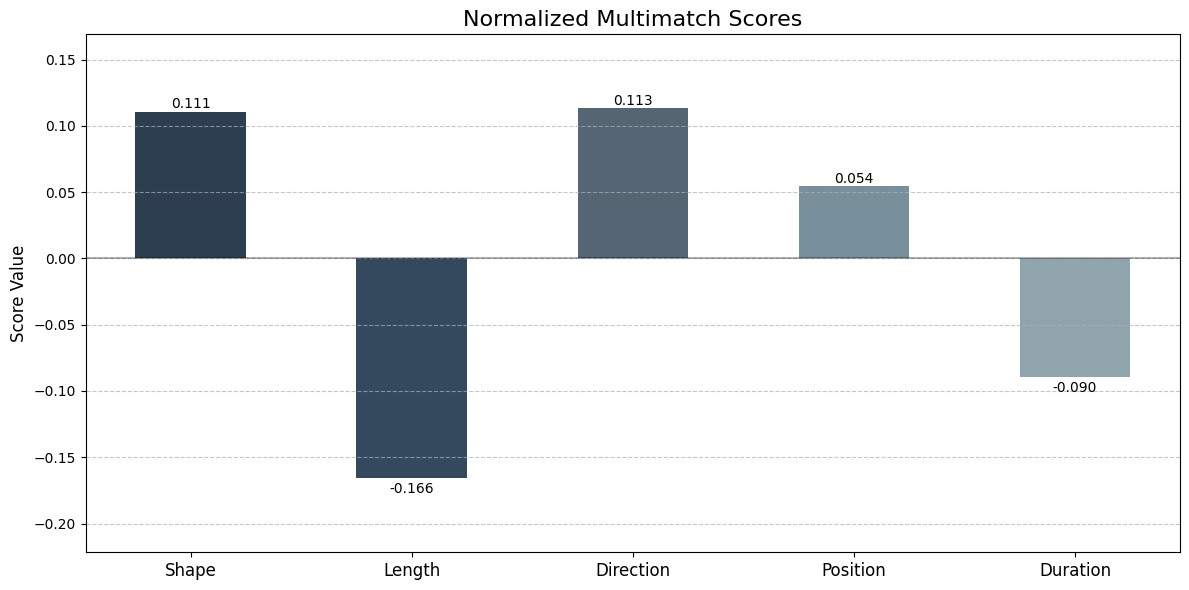

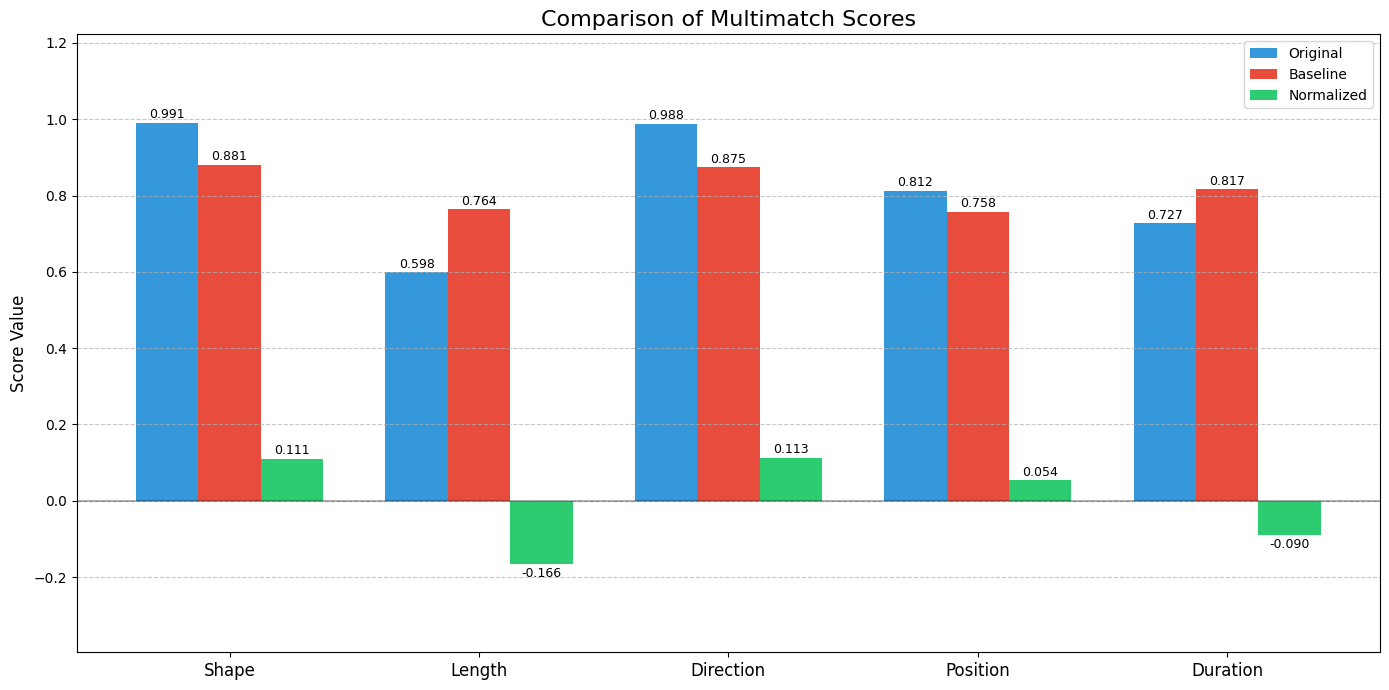

In [6]:
from tools import path_similarity
import matplotlib.pyplot as plt

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events
)

path_similarity.auxiliary.visualize_multimatch_scores(scores, "Normalized Multimatch Scores")
plt.show()

path_similarity.auxiliary.visualize_all_scores(scores)
plt.show()

Compute path similarity by using scasim (part of ScanDL)

In [7]:
# parameter normalize can be 'durations', 'fixations' or 'None'
# It actually compute Scan path difference
result = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    normalize = 'duration'
)

print("Scasim score:", result)

Scasim score: 0.8506936803968832


Compute NLD for both scanpath

In [8]:
distance, nld = path_similarity.nld_for_original(exp_a, exp_b, eye_events)

print(f"Distance: {distance}, NLD: {nld}")

Distance: 337.0, NLD: 0.9711815561959655
